### on continue au propre

In [1]:
import skimage as skim
import sklearn 
import cv2
import numpy as np
import os

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import napari
%load_ext autoreload
%autoreload 2
import _utils

In [40]:
train_data_path = '../data/dataset_project_iapr2025/train/'
img = np.array(Image.open(train_data_path + 'L1000791.JPG'))
binned = _utils.median_bin_rgb(img, block_size=(10, 10))

binned_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
binned_hsv = cv2.cvtColor(binned_bgr, cv2.COLOR_BGR2HSV)

spx = skim.segmentation.slic(binned, n_segments=5000, compactness=.1, sigma=1, start_label=0)

In [41]:
hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)
gmm = _utils.gmm_on_spx_fit(range(1,15), hsv_feat)
labels = _utils.gmm_on_spx_predict(gmm, hsv_feat[spx], spx)

In [42]:
viewer = napari.Viewer()
viewer.add_image(binned)
viewer.add_labels(labels)
napari.run()

label0: [0.06575446 0.00597507 0.68461581],  dist to ref: 0.507937270450971
label1: [0.42144736 0.03101494 0.70026159],  dist to ref: 0.6104892708814326
label2: [0.1016077  0.44547012 0.37213075],  dist to ref: 0.13198152162102256
label3: [0.48570184 0.01090422 0.68338364],  dist to ref: 0.6595654346270988
label4: [0.12413202 0.01919017 0.67927123],  dist to ref: 0.4979271183583855
label5: [0.06890494 0.16704416 0.57692308],  dist to ref: 0.32064525297644536
label6: [0.26084294 0.00660543 0.68621338],  dist to ref: 0.5465844543094605
label7: [0.43098772 0.16236394 0.4959355 ],  dist to ref: 0.4868914819005668


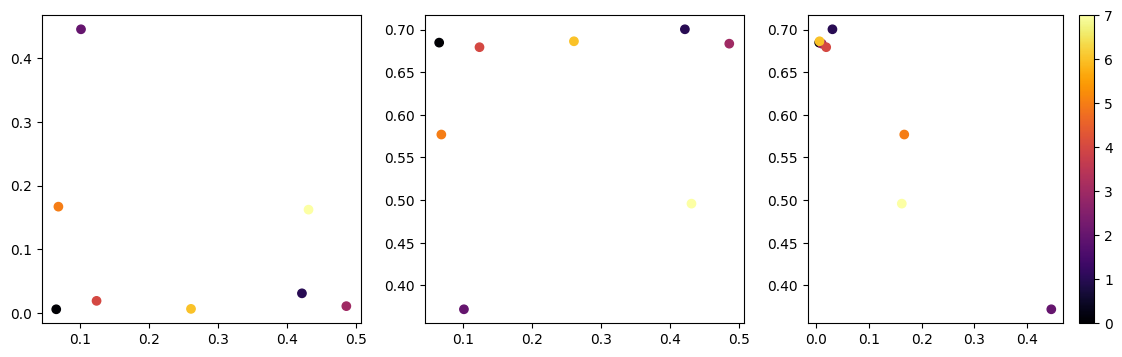

In [43]:
labels_mean = np.zeros((np.max(labels)+1,3))
ref = np.array([0.0589036,  0.47638436, 0.49312576])
for i in range(len(labels_mean)):
    labels_mean[i] = np.mean(binned_hsv[labels==i], axis=0)/255
    dist_to_ref=np.linalg.norm(labels_mean[i]-ref)
    print(f'label{i}: {labels_mean[i]},  dist to ref: {dist_to_ref}')


plt.figure(figsize=(14,4))
plt.subplot(1, 3, 1)
plt.scatter(labels_mean[:,0], labels_mean[:,1], cmap='inferno', c=np.arange(labels_mean.shape[0]))
plt.subplot(1, 3, 2)
plt.scatter(labels_mean[:,0], labels_mean[:,2], cmap='inferno', c=np.arange(labels_mean.shape[0]))
plt.subplot(1, 3, 3)
plt.scatter(labels_mean[:,1], labels_mean[:,2], cmap='inferno', c=np.arange(labels_mean.shape[0]))
plt.colorbar()
plt.show()

### Region Growing

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

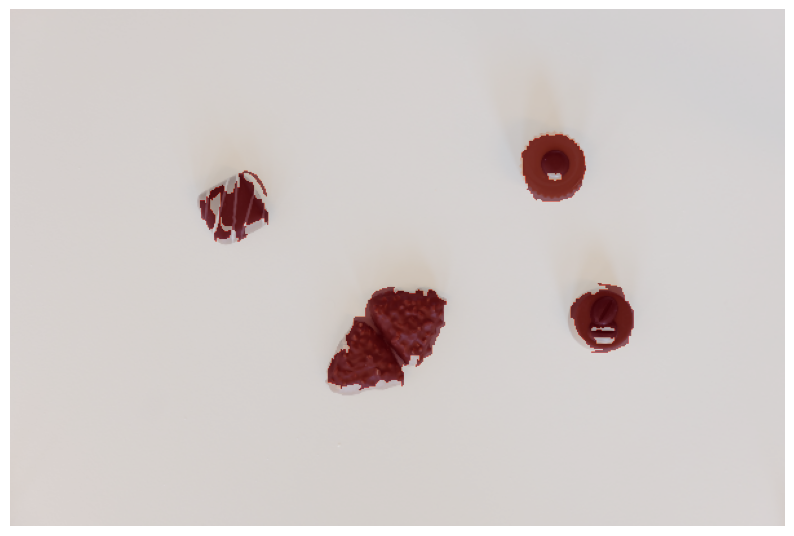

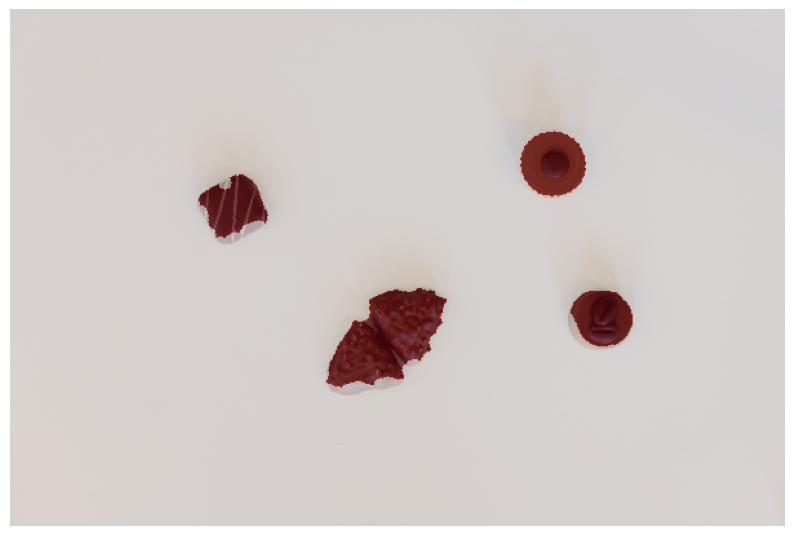

In [44]:
chosen_label = (labels == 2)

plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(chosen_label, alpha=0.5, cmap='Reds')
plt.axis('off')

binned_hsv = _utils.rgb_to_hsv(binned)

rg_mask = _utils.region_growing(binned, binned_hsv, chosen_label)

plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(rg_mask, alpha=0.5, cmap='Reds')
plt.axis('off')

### Water shed

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

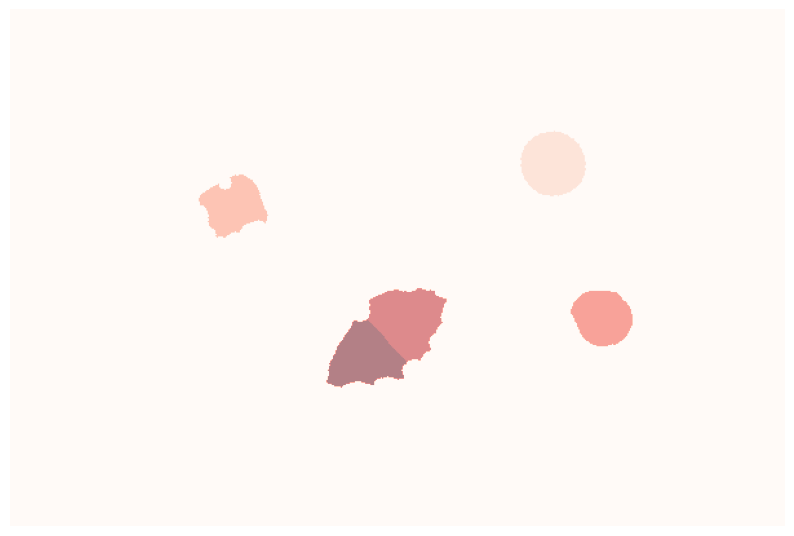

In [46]:
labels = _utils.watershed(rg_mask)

plt.figure(figsize=(10, 10))
plt.imshow(labels, alpha=0.5, cmap='Reds')
plt.axis('off')

### Test sur tout le dataset

In [55]:
test_data_path = '../data/dataset_project_iapr2025/test'
save_data_path = '../data/dataset_project_iapr2025/binary_masks'

for filename in tqdm(os.listdir(test_data_path)):
    full_path = os.path.join(test_data_path, filename)
    if os.path.isfile(full_path):
        img = np.array(Image.open(full_path))
        binned = _utils.median_bin_rgb(img, block_size=(10, 10))

        binned_hsv = _utils.rgb_to_hsv(binned)

        spx = skim.segmentation.slic(binned, n_segments=5000, compactness=.1, sigma=1, start_label=0)

        hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)
        gmm = _utils.gmm_on_spx_fit(range(1,15), hsv_feat)
        labels = _utils.gmm_on_spx_predict(gmm, hsv_feat[spx], spx)

        labels_mean = np.zeros((np.max(labels)+1,3))
        ref = np.array([0.1, 0.6, 0.4])
        for i in range(len(labels_mean)):
            labels_mean[i] = np.mean(binned_hsv[labels==i], axis=0)/255
        dists_to_ref = np.linalg.norm(labels_mean - ref, axis=1)
        binary = labels==np.argmin(dists_to_ref)

        plt.figure(figsize=(9,6))
        plt.imshow(binned)
        plt.imshow(binary, alpha=0.7, cmap='inferno')
        plt.axis('off')
        plt.savefig(save_data_path+'/'+filename)
        plt.close()

        rg_mask = _utils.region_growing(binned, binned_hsv, binary)

        labels = _utils.watershed(rg_mask)

        labels *= rg_mask

        name, ext = os.path.splitext(filename)
        new_filename = name + '_2' + ext

        plt.figure(figsize=(9,6))
        plt.imshow(binned)
        plt.imshow(labels, alpha=0.7, cmap='inferno')
        plt.axis('off')
        plt.savefig(save_data_path+'/'+new_filename)
        plt.close()

  2%|▏         | 3/180 [00:52<53:44, 18.22s/it]c:\Users\timothe\workspace\Image\ImageEnv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\timothe\workspace\Image\ImageEnv\Lib\site-packages\numpy\_core\_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
  5%|▌         | 9/180 [02:18<40:59, 14.38s/it]c:\Users\timothe\workspace\Image\ImageEnv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\timothe\workspace\Image\ImageEnv\Lib\site-packages\numpy\_core\_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
  8%|▊         | 14/180 [03:26<37:17, 13.48s/it]c:\Users\timothe\workspace\Image\ImageEnv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis